# Badanie Efektywności Reprezentacji Ortogonalnej Sygnałów 1D

Autorzy:
- Grzegorz Cyba, 274859
- Jan Galewicz 272587

---

## 1. Wstęp



wybrany temat

co chcemy zrobić aka założenia

krótki opis fouriera

zastosowania - do czego się używa

wszystko krótko bo dalej będzie rozwinięte

---

## 2. Generator danych

W celu przeprowadzenia kompleksowej weryfikacji efektywności algorytmu kompresji widmowej opartego na transformacie Fouriera, niezbędne było przygotowanie zróżnicowanego materiału badawczego. Zaimplementowane środowisko pozwala na generowanie trzech klas sygnałów o odmiennych właściwościach w domenie czasu i częstotliwości. Pozwala to na rygorystyczne przetestowanie mechanizmu progowania współczynników pod kątem dokładności rekonstrukcji, zachowania energii oraz zmian entropii sygnału.

### 2.1. Budowa zbioru danych i symulacja zaszumienia pomiarowego

Masowa synteza oraz agregacja struktur sygnałowych realizowana jest przez klasę zarządczą *DatasetCreator*. Narzędzie to automatyzuje proces budowy zbalansowanego datasetu testowego w dyskretnej dziedzinie czasu dla następujących parametrów:
- $t_0 = 0\text{ s}$ — czas początkowy przebiegu,
- $t_{end} = 500\text{ s}$ — czas końcowy przebiegu,
- $dt = 0.1\text{ s}$ — krok czasowy (co daje wektor o długości 5000 próbek),
- $u(t) \in [1, 10]$ — zakres dopuszczalnych wartości (amplitud).

**Powtarzalność i determinizm widma:**

W celu zapewnienia pełnej replikowalności eksperymentów, klasa wykorzystuje obiektowy generator liczb pseudolosowych `np.random.default_rng(seed)`. Przekazywanie tej samej instancji stanu losowego (`rng`) do klas sygnałowych gwarantuje, że przy identycznym ziarnie (seed) wygenerowane trajektorie czasowe oraz ich struktura spektralna (układ harmonicznych w widmie) będą identyczne przy każdym uruchomieniu.

**Separacja danych czystych i zaszumionych:**

Architektura generatora wymusza ścisły podział na fazę syntezy oraz fazę eksperymentu szumowego:
1. **Generowanie bazy** (`create_dataset`): Tworzy i zapisuje w instancji (`self.dataset`) wyłącznie idealnie czyste, referencyjne trajektorie dla każdej z trzech klas sygnałów.
2. **Generowanie zakłóceń** (`create_noisy_dataset_copy`): Tworzy głęboką kopię (`deepcopy`) czystego zbioru bazowego i nakłada na nią szum Gaussowski o intensywności zdefiniowanej przez parametr `noise_level` ($\sigma$). Pozwala to na rygorystyczne badanie wpływu kompresji Fouriera na ten sam sygnał przy różnych poziomach zakłóceń, bez niszczenia danych źródłowych.

Proces zaszumiania kopii realizowany jest zgodnie z zależnością:

$$y_{noisy} = y_{clean} + N(0, \sigma)$$

Aby wartości sygnału po zaszumieniu nie przekroczyły barier fizycznych, końcowy wektor poddawany jest operacji saturacji do przedziału $[u_{min}, u_{max}]$ za pomocą funkcji `np.clip`. Wygenerowane pakiety danych (wektory $t$ oraz $y$) są ostatecznie kapsułkowane w ustrukturyzowanych obiektach klasy `SignalData` i mapowane w zbiorczym słowniku pod kluczami *aprbs*, *multisine* oraz *noise*.

### 2.2 Klasy sygnałów

Każda z zaimplementowanych klas sygnału reprezentuje inny typ struktury spektralnej, co pozwala na ocenę uniwersalności projektowanego kodeka.


#### 2.2.1. Sygnał APRBS (Amplitude Pseudo-Random Binary Sequence)


Sygnał ten charakteryzuje się gwałtownymi, dyskretnymi zmianami amplitudy (skokami napięcia) utrzymywanymi przez losowy czas. Dla każdego pojedynczego przebiegu parametry czasowe są losowane stochastycznie z następujących zakresów:
- $h_{min} \in [50; 150]$ — zakres, z którego losowany jest minimalny czas trwania pojedynczego kroku,
- $h_{add} \in [100; 300]$ — przedział definiujący dodatkowy czas, który po zsumowaniu z $h_{min}$ określa maksymalny czas trwania kroku ($h_{max}$).

Znaczenie w analizie kompresji: Z punktu widzenia analizy Fouriera, ostre zbocza i nieskończony gradient zmian w dziedzinie czasu generują ciągłe, bardzo bogate spektrum częstotliwościowe o wolno wygasających harmonicznych. Jest to najtrudniejszy test dla algorytmu kompresji widmowej. Wycięcie wysokich częstotliwości (współczynników FFT) prowadzi do utraty ostrości krawędzi i generuje charakterystyczne oscylacje wokół punktów skoku po wykonaniu odwrotnej transformaty (tzw. efekt Gibbsa). Pozwala to zbadać, jak mocno ucinanie pasma zniekształca skokowe sygnały szybkozmienne.

In [ ]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=0, n_noise=0)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9], signals_noisy=dataset_noisy['aprbs'], noise_level=creator.noise_level)


#### 2.2.2. Sygnał Multisine (Wieloczęstotliwościowy)

Sygnał ten stanowi deterministyczną sumę składowych harmonicznych (sinusoid) o losowych fazach i częstotliwościach. Dla każdego przebiegu parametry konfiguracyjne losowane są z przedziałów:
- $n_f \in [5; 15]$ — zakres, z którego losowana jest liczba składowych sinusoidalnych,
- $f_{max} \in [0.005; 0.02]\text{ Hz}$ — zakres, z którego losowana jest maksymalna dopuszczalna częstotliwość pojedynczej sinusoidy.

Znaczenie w analizie kompresji: W dziedzinie częstotliwości sygnał ten charakteryzuje się ściśle dyskretnym spektrum prążkowym. Cała energia sygnału skupiona jest w dokładnie $n_f$ punktach widma, podczas gdy pozostała część pasma przyjmuje wartości zerowe. Dla kodeka fourierowskiego jest to sygnał idealny. Algorytm progowania powinien bezbłędnie wyizolować i zachować wyłącznie dominujące prążki częstotliwościowe, co pozwala na uzyskanie minimalnego błędu rekonstrukcji (MSE) i stabilnej entropii widmowej nawet przy bardzo niskim procencie zachowanych danych.

In [ ]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=10, n_noise=0)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9], signals_noisy=dataset_noisy['multisine'], noise_level=creator.noise_level)

#### 2.2.3. Przefiltrowany szum dolnoprzepustowy (Filtered Noise)

Sygnał reprezentujący przebieg chaotyczny o kontrolowanym paśmie. Powstaje poprzez generację stochastycznego szumu białego o rozkładzie normalnym, który następnie poddawany jest cyfrowej filtracji dolnoprzepustowej pierwszego rzędu. Częstotliwość odcięcia filtra jest parametrem losowym:
- $cutoff \in [0.001; 0.01]\text{ Hz}$ — zakres losowania częstotliwości odcięcia.

Znaczenie w analizie kompresji: W dziedzinie częstotliwości sygnał ten posiada gęste, ciągłe pasmo szumowe ograniczone od góry filtrem wygładzającym. Brak pojedynczych, dominujących częstotliwości sprawia, że energia jest rozproszona. Pozwala to na zbadanie, jak algorytm kompresji radzi sobie z sygnałami stochastycznymi, gdzie ucinanie współczynników przekłada się bezpośrednio na liniową utratę losowej energii tła, co stanowi kluczowy punkt weryfikacji zmian entropii widmowej oraz dokładności odwzorowania szumów procesowych.

In [ ]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.5, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=0, n_noise=10)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9], signals_noisy=dataset_noisy['noise'], noise_level=creator.noise_level)

---

## 3. Fourier



podstawy teoretyczne (DFT)
- prosty
- odwrotny

opis kodu w markdown

kod do uruchomienia
- wykresy jak działa ucinanie (kompresja)
- mse
- przykładowe porównanie numpy vs własne

---

## 4. Strategie kompresji

COŚ

### 4.1. Algorytm oparty na analizie energii

Istotą podejścia energetycznego do kompresji w dziedzinie częstotliwości jest usunięcie tych składowych spektralnych, które wnoszą zaniedbywalnie mały udział do całkowitej energii sygnału. Podstawą matematyczną tej metody jest twierdzenie Parsevala, które mówi, że całkowita energia sygnału obliczona w dziedzinie czasu jest równa całkowitej energii jego transformaty w dziedzinie częstotliwości:

$$\sum_{n=0}^{N-1} |y[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |Y[k]|^2$$

Gdzie:
* $y[n]$ — próbki sygnału w dziedzinie czasu,
* $Y[k]$ — zespolone współczynniki uzyskane z dyskretnej transformaty Fouriera (DFT).

Ponieważ widmo sygnałów rzeczywistych cechuje się symetrią sprzężoną wokół częstotliwości Nyquista, algorytm operuje na modułach wszystkich współczynników $|Y[k]|$ w pełnym zakresie pasma $[0, f_s)$. W procesie sortowania spektralnego symetryczne pary dominujących prążków są naturalnie pozycjonowane obok siebie, co pozwala na zachowanie bilansu energetycznego bez konieczności manualnej redukcji wymiarowości wektora.

#### Przebieg procedury kompresji energetycznej

W celu numerycznej weryfikacji algorytmu, w strukturze skryptu testowego wydzielono trzy główne etapy przetwarzania sygnału częstotliwościowego. Poniższy opis szczegółowo definiuje operacje realizowane w każdym z kluczowych punktów programu:

1. **Wyznaczenie widma autorską metodą:** W tym kroku obiekt klasy `DiscreteFourier` przyjmuje wektory czasu (`signal.t`) oraz wartości sygnału (`signal.y`), a następnie wyznacza dyskretną transformatę Fouriera za pomocą metody `transform()`. Wynikiem działania są dwa wektory: `omega_vec` (zawierający fizyczne częstotliwości wyrażone w Hz) oraz `f_omega_vec` reprezentujący pełne, obustronne widmo zespolone o długości równej liczbie próbek wejściowych $N$.

2. **Analiza rozkładu energii:** Etap ten odpowiada za wyznaczenie optymalnej liczby współczynników spektralnych $K$ na podstawie zdefiniowanego przez użytkownika kryterium zachowania energii (`energy_threshold`). Wewnętrzna logika metody `analyze_energy_distribution` realizowana jest poprzez następujące kroki cząstkowe:
   * **2.1. Obliczenie gęstości widmowej mocy:** Konwersja zespolonych współczynników $Y[k]$ na wartości rzeczywiste określające moc prążków poprzez obliczenie kwadratu ich modułu (`np.abs(coeffs)**2`).
   * **2.2. Wyznaczenie energii całkowitej widma:** Obliczenie sumarycznej energii w dziedzinie częstotliwości z uwzględnieniem skalowania przez długość sygnału $N$. Wartość ta (`total_energy_freq`) stanowi bezpośredni odpowiednik energii czasowej sygnału pierwotnego.
   * **2.3. Sortowanie spektralne:** Uszeregowanie wszystkich składowych mocy od wartości największej do najmniejszej. Krok ten pozwala na natychmiastową lokalizację dominujących harmonicznych sygnału.
   * **2.4. Wyznaczenie profilu akumulacji energii:** Program tworzy wektor, który działa jak "licznik" zgromadzonej energii (`np.cumsum`). Idąc od najsilniejszego prążka do najsłabszego, algorytm dodaje energię kolejnych współczynników i sprawdza, jaki procent energii całkowitej już zebrał (wartość ta rośnie od 0 do 1, czyli do 100%).
   * **2.5. Ekstrakcja indeksu granicznego $K$:** Wykorzystanie operacji logicznej i funkcji poszukiwania pierwszego indeksu spełniającego warunek brzegowy (`np.argmax(...) + 1`). Zwracana wartość `k_threshold` definiuje precyzyjnie, ile największych prążków widma należy zachować, aby nie przekroczyć narzuconego limitu strat.

3. **Kompresja (Przycięcie widma) i rekonstrukcja sygnału:** W ostatniej fazie wyznaczona wartość `k_threshold` przekazywana jest wraz z bazowym widmem do metody statycznej `trim_spectrum()`. Funkcja ta wyznacza próg amplitudy dla $K$-tego największego współczynnika, a następnie tworzy maskę logiczną, która zachowuje nienaruszone prążki dominujące, a wszystkie pozostałe, mało istotne energetycznie składowe (szum, fluktuacje) nadpisuje wartością zero. Skompresowany w ten sposób wektor częstotliwości (`f_trimmed`) trafia do metody `inverse_transform()`, gdzie za pomocą algorytmu IDFT następuje synteza czysto rzeczywistego sygnału wyjściowego `y_reconstructed`.

Efektem działania algorytmu jest drastyczne zredukowanie liczby niezerowych elementów w wektorze częstotliwości. Przekłada się to bezpośrednio na wysoki stopień kompresji danych przy jednoczesnym ścisłym, matematycznym kontrolowaniu dopuszczalnych strat informacji, co potwierdza końcowy bilans energetyczny sygnału skompresowanego (`e_time_reconstructed`).

Generowanie APRBS:   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie MULTISINE:   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie NOISE:   0%|          | 0/10 [00:00<?, ?it/s]

--- ANALIZA ENERGII - SYGNAŁ APRBS - WŁASNA FFT ---
Liczba współczynników (K) dla 99.0% energii: 51


Rodzaj pomiaru energii,Wartość
1. Oryginalny sygnał (Dziedzina czasu),199496.02
2. Oryginalny sygnał (Dziedzina częstotliwości),199496.02
3. Zrekonstruowany sygnał (Po kompresji K=51),197501.95
Faktyczna strata energii po kompresji,1.00%


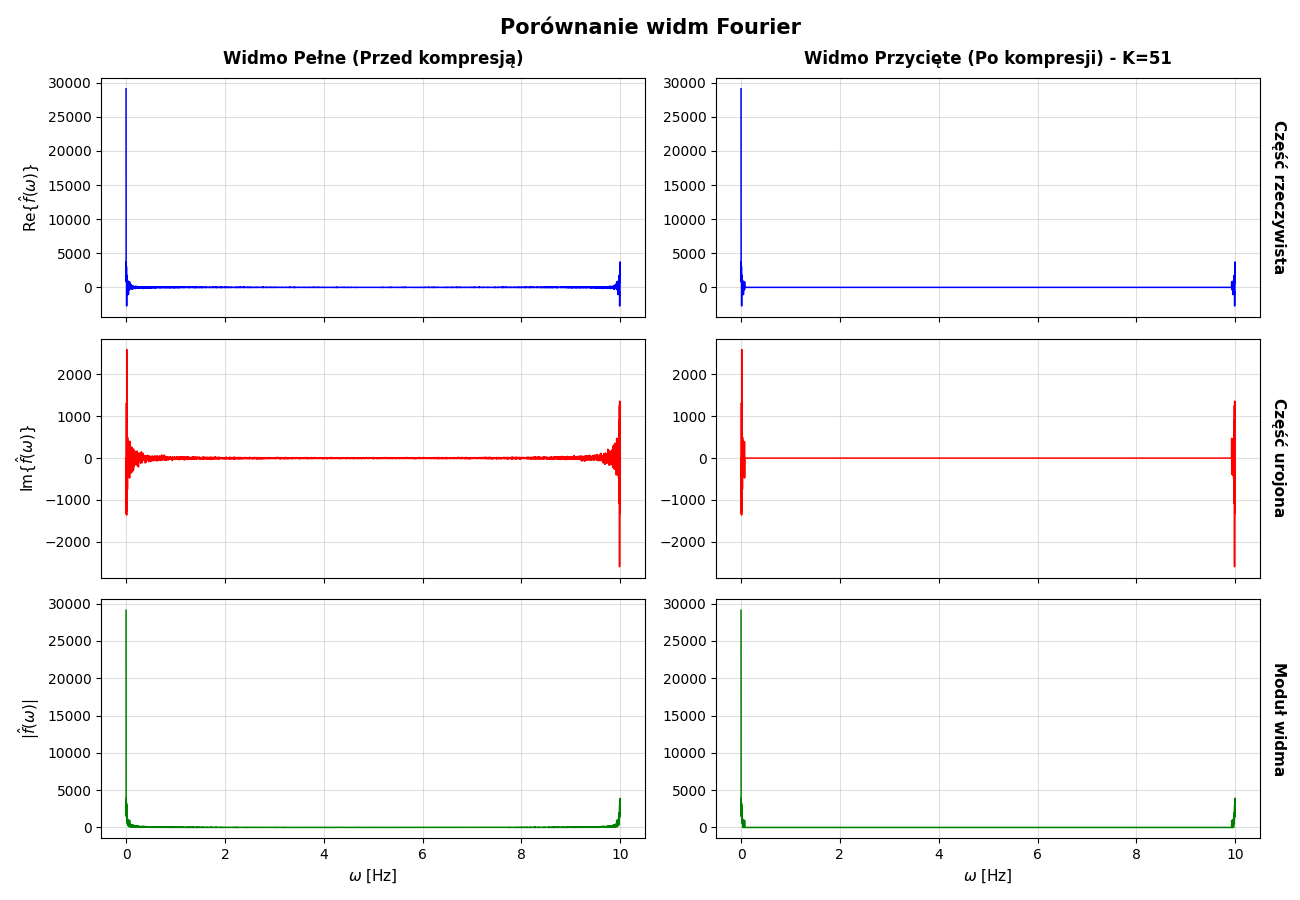

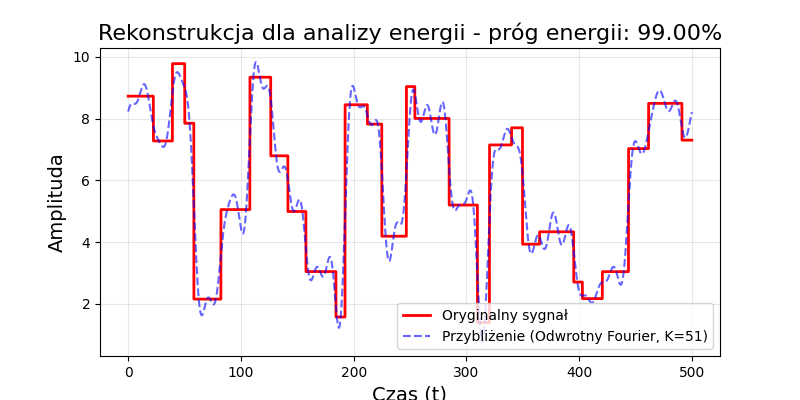

--- ANALIZA ENERGII - SYGNAŁ APRBS - WŁASNA FFT ---
Liczba współczynników (K) dla 99.0% energii: 53


Rodzaj pomiaru energii,Wartość
1. Oryginalny sygnał (Dziedzina czasu),199506.99
2. Oryginalny sygnał (Dziedzina częstotliwości),199506.99
3. Zrekonstruowany sygnał (Po kompresji K=53),197545.99
Faktyczna strata energii po kompresji,0.98%


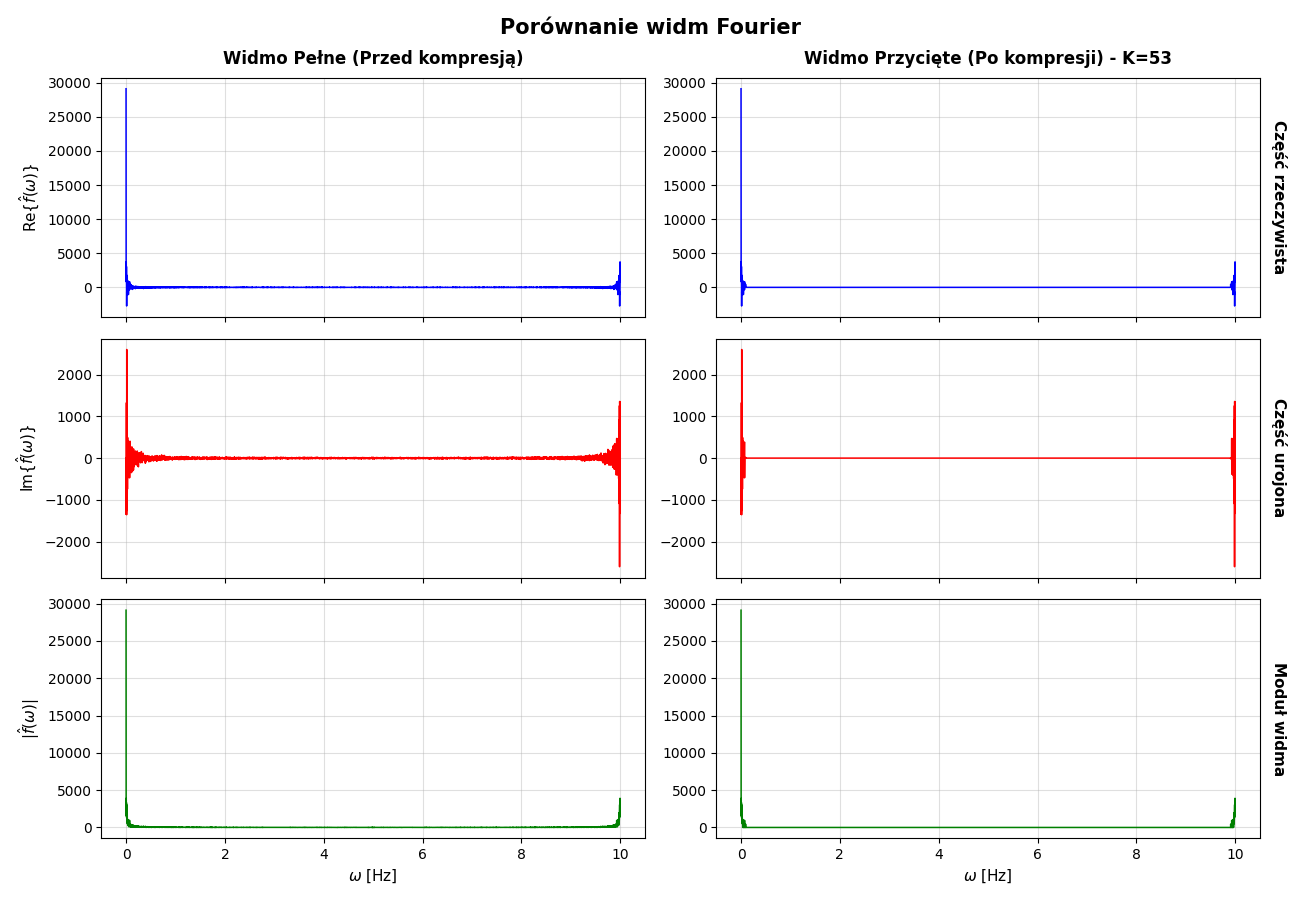

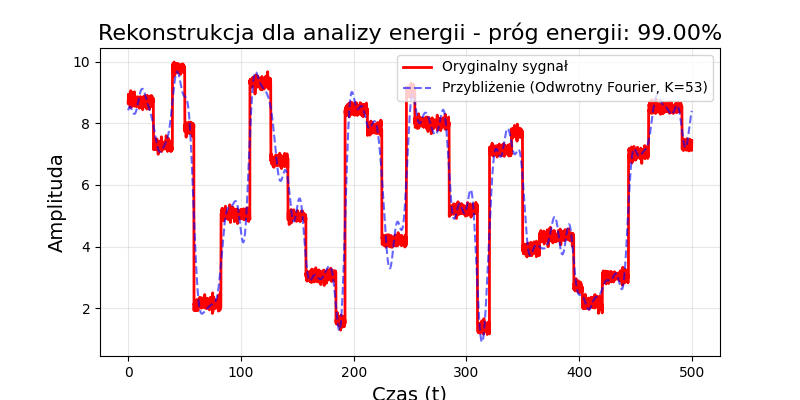

In [ ]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Fourier import DiscreteFourier
from EnergyAnalyzer import EnergyAnalyzer
from Plotter import Plotter
from tabulate import tabulate
from TableRenderer import ReportTableRenderer


# Inicjalizacja generatora i pobranie sygnału Multisine
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.1, seed=42)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

# Wybór sygnału do analizy (można wybrać: 'aprbs', 'multisine', 'noise')
signal_type = 'aprbs'
signal = dataset[f'{signal_type}'][0]

# Obliczenie energii w czasie do porównania z energią w dziedzinie częstotliwości
e_time = EnergyAnalyzer.calculate_total_energy(signal.y)

# ----------------------------------------------------------------------------------
print(f"--- ANALIZA ENERGII - SYGNAŁ {signal_type.upper()} - WŁASNA FFT ---")

# 1. Wyznaczenie widma autorską metodą
fourier_engine = DiscreteFourier(signal.t, signal.y)
omega_vec, f_omega_vec = fourier_engine.transform()

# 2. Analiza rozkładu energii (próg 99.9%)
energy_threshold = 0.99
results_dsc = EnergyAnalyzer.analyze_energy_distribution(f_omega_vec, N=len(signal.y), threshold=energy_threshold)
print(f"Liczba współczynników (K) dla {energy_threshold*100}% energii: {results_dsc['k_threshold']}")

# 3. Kompresja - zerowanie nieistotnych składowych i rekonstrukcja sygnału
f_trimmed = fourier_engine.trim_spectrum(f_omega_vec=f_omega_vec, k=results_dsc['k_threshold'])
y_reconstructed = fourier_engine.inverse_transform(f_trimmed)

# ----------------------------------------------------------------------------------

# Obliczenie energii zrekonstruowanego sygnału do porównania z energią oryginalnego sygnału
e_time_reconstructed = EnergyAnalyzer.calculate_total_energy(y_reconstructed)

# Tabela porównująca energię w dziedzinie czasu, energię w dziedzinie częstotliwości oraz energię zrekonstruowanego sygnału po kompresji
headers = ["Rodzaj pomiaru energii", "Wartość"]
rows = [
    ["1. Oryginalny sygnał (Dziedzina czasu)", f"{e_time:.2f}"],
    ["2. Oryginalny sygnał (Dziedzina częstotliwości)", f"{results_dsc['total_energy_freq']:.2f}"],
    [f"3. Zrekonstruowany sygnał (Po kompresji K={results_dsc['k_threshold']})", f"{e_time_reconstructed:.2f}"],
    ["Faktyczna strata energii po kompresji", f"{(1.0 - (e_time_reconstructed / e_time)) * 100:.2f}%"]
]
ReportTableRenderer.render(
    title=f"Bilans energetyczny sygnału (Próg: {energy_threshold*100}%)",
    headers=headers,
    rows=rows
)

# Wizualizacja porównania widm i rekonstrukcji
Plotter.plot_fourier_comparison_widma(omega_vec, f_omega_vec, f_trimmed, K=results_dsc['k_threshold'], title="Porównanie widm Fourier")
Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    y_reconstructed, 
    K=results_dsc['k_threshold'],
    title=f"Rekonstrukcja dla analizy energii - próg energii: {energy_threshold*100:.2f}%"
)


### 4.2 Algorytm oparty na analizie dokładności (MSE / Max Error): 
Opis funkcji iteracyjnej. Jak algorytm dokłada/odbiera współczynniki i wykonuje odwrotne IFFT, dopóki sygnał rekonstruowany nie zmieści się w zadanym progu błędu średniokwadratowego ($MSE$) lub błędu maksymalnego ($E_{max}$).

In [ ]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import DiscreteFourier
from FidelityAnalyzer import FidelityAnalyzer

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

signal_type = 'noise'
signal = dataset[f'{signal_type}'][0]

print(f"--- ANALIZA SYGNAŁU {signal_type.upper()} - WŁASNA FFT ---")

# 2. Wyznaczenie widma autorską metodą
fourier_engine = DiscreteFourier(signal.t, signal.y)
omega_vec, f_omega_vec = fourier_engine.transform()

max_allowed_diff = 0.2 
mode = 'mse'  #'max_error' jeśli  maksymalny błąd zamiast MSE
# mode = 'max_error'  # Użyj tej linii zamiast powyższej, jeśli chcesz analizować maksymalny błąd
results = FidelityAnalyzer.analyze_by_error(signal.y, f_omega_vec, threshold=max_allowed_diff, mode=mode)

print(f"Aby błąd maksymalny był < {max_allowed_diff}, potrzeba K = {results['k_threshold']}")

# 5. Wizualizacja porównania widm i rekonstrukcji
Plotter.plot_fourier_comparison_widma(omega_vec, f_omega_vec, f_trimmed, K=results_dsc['k_threshold'], title="Porównanie widm Fourier")
Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    results['reconstructed_y'], 
    K=results['k_threshold'],
    title=f"Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}"
)

---

## 5. Testy



### 5.1 Założenia testowe

Definicja środowiska: jakie zestawy danych badasz (czysty vs zaszumiony stworzony z kopii), jakie progi energii (np. $90\%, 95\%, 99\%$) i błędu (np. $MSE < 0.01$) przyjmujesz do testów masowych.



### 5.3 Testy ilościowe algorytmów kompresji (Analiza Energii vs Analiza Dokładności)

#### 5.3.1. Efektywność kompresji dla sygnałów APRBS:

(Jak gwałtowne skoki wpływają na liczbę wymaganych współczynników w obu podejściach i jak przejawia się efekt Gibbsa).

#### 5.3.2. Efektywność kompresji dla sygnałów Multisine: 

(Pokazanie, że oba algorytmy idealnie wycinają zbędne tło i zostawiają tylko dominujące prążki).

#### 5.3.3. Efektywność kompresji dla przefiltrowanego szumu:

(Analiza zachowania filtracji przy rozproszonym widmie).


 
#### kod


In [ ]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=20, n_multisine=20, n_noise=20)

tester = FidelityTester(big_dataset)

# Testy z naszą transformatą są długie (około 10 min)
stats = tester.run(threshold=1.0, mode='mse', use_custom_fft=True)

print("--- RAPORT KOSZTU REPREZENTACJI (K) ---")
print(tester.display_results())


### 5.5 Analiza wyników
parametry generatorów
zapisane wykresy i tabele
analiza

---

## 5. Kompresja Audio

co to wav

zastosowanie

własny koder i dekoder

kod do uruchomienia

wykresy i tabele

Analiza

---

## 6. Podsumowanie